In [5]:
#Instalacion
!pip install spacy
!python -m spacy download en_core_web_sm

# Librerías

import pandas as pd
import numpy as np
import spacy

from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 47.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [8]:
# Modelo

nlp = spacy.load("en_core_web_sm")

In [12]:
# Carga de Dataset

df = pd.read_csv(
    "Amazon_Reviews.csv",
    encoding="utf-8",
    engine="python",
    on_bad_lines="skip"
)

print(df.shape)
df.head()

(21214, 9)


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [13]:
# Inspeccion Inicial

print(df.shape)

df.head()

print(df.columns)

(21214, 9)
Index(['Reviewer Name', 'Profile Link', 'Country', 'Review Count',
       'Review Date', 'Rating', 'Review Title', 'Review Text',
       'Date of Experience'],
      dtype='object')


In [15]:
# Selección de texto

texts = df["Review Text"].dropna().astype(str)

texts.head()

,Review Text
0,"I registered on the website, tried to order a ..."
1,Had multiple orders one turned up and driver h...
2,I informed these reprobates that I WOULD NOT B...
3,I have bought from Amazon before and no proble...
4,If I could give a lower rate I would! I cancel...


In [16]:
df = df[["Review Text", "Rating"]]

df.columns = ["text", "rating"]

df.head()

,text,rating
0,"I registered on the website, tried to order a ...",Rated 1 out of 5 stars
1,Had multiple orders one turned up and driver h...,Rated 1 out of 5 stars
2,I informed these reprobates that I WOULD NOT B...,Rated 1 out of 5 stars
3,I have bought from Amazon before and no proble...,Rated 1 out of 5 stars
4,If I could give a lower rate I would! I cancel...,Rated 1 out of 5 stars


In [17]:
# Tokenización

sample_text = texts.iloc[0]

doc = nlp(sample_text)

tokens = [token.text for token in doc]

tokens[:50]

['I',
 'registered',
 'on',
 'the',
 'website',
 ',',
 'tried',
 'to',
 'order',
 'a',
 'laptop',
 ',',
 'entered',
 'all',
 'the',
 'details',
 ',',
 'but',
 'instead',
 'of',
 'charging',
 'me',
 'and',
 'sending',
 'the',
 'product',
 ',',
 'they',
 'froze',
 'my',
 'account',
 ',',
 'demanding',
 'various',
 'verification',
 'documents',
 '.',
 'I',
 'sent',
 'them',
 'over',
 '.',
 'They',
 'said',
 'they',
 'would',
 'review',
 'them',
 'within',
 '24']

In [18]:
# Eliminación de Stopwords Estándar

def remove_stopwords(text):

    doc = nlp(text)

    return [
        token.text.lower()
        for token in doc
        if not token.is_stop
        and token.is_alpha
    ]

clean_tokens = remove_stopwords(sample_text)

clean_tokens[:50]

['registered',
 'website',
 'tried',
 'order',
 'laptop',
 'entered',
 'details',
 'instead',
 'charging',
 'sending',
 'product',
 'froze',
 'account',
 'demanding',
 'verification',
 'documents',
 'sent',
 'said',
 'review',
 'hours',
 'reality',
 'week',
 'help',
 'truthful',
 'estimate',
 'resolved',
 'tell',
 'wait',
 'seen',
 'horrible',
 'marketplace',
 'life',
 'hope',
 'came',
 'buy',
 'food',
 'store',
 'receiving',
 'document',
 'review',
 'request',
 'takes',
 'forever',
 'process']

In [19]:
# Markdown

custom_stopwords = {
    "product",
    "amazon",
    "item"
}

def remove_custom_stopwords(text):

    doc = nlp(text)

    return [
        token.text.lower()
        for token in doc
        if not token.is_stop
        and token.is_alpha
        and token.text.lower()
        not in custom_stopwords
    ]

In [20]:
# Comparacion de Frecuencias

all_tokens_before = []

for text in texts.head(1000):

    doc = nlp(text)

    all_tokens_before.extend(
        [
            token.text.lower()
            for token in doc
            if token.is_alpha
        ]
    )

all_tokens_after = []

for text in texts.head(1000):

    all_tokens_after.extend(
        remove_custom_stopwords(text)
    )

In [21]:
# Top palabras antes

before_freq = Counter(
    all_tokens_before
)

before_df = pd.DataFrame(
    before_freq.most_common(10),
    columns=["Word","Frequency"]
)

before_df

,Word,Frequency
0,the,3371
1,i,3303
2,to,3200
3,and,2769
4,a,2103
5,they,1635
6,amazon,1620
7,it,1435
8,my,1211
9,for,1118


In [22]:
# Top palabras despues

after_freq = Counter(
    all_tokens_after
)

after_df = pd.DataFrame(
    after_freq.most_common(10),
    columns=["Word","Frequency"]
)

after_df

,Word,Frequency
0,customer,566
1,service,553
2,delivery,500
3,order,368
4,refund,356
5,time,325
6,prime,265
7,day,253
8,items,246
9,delivered,241


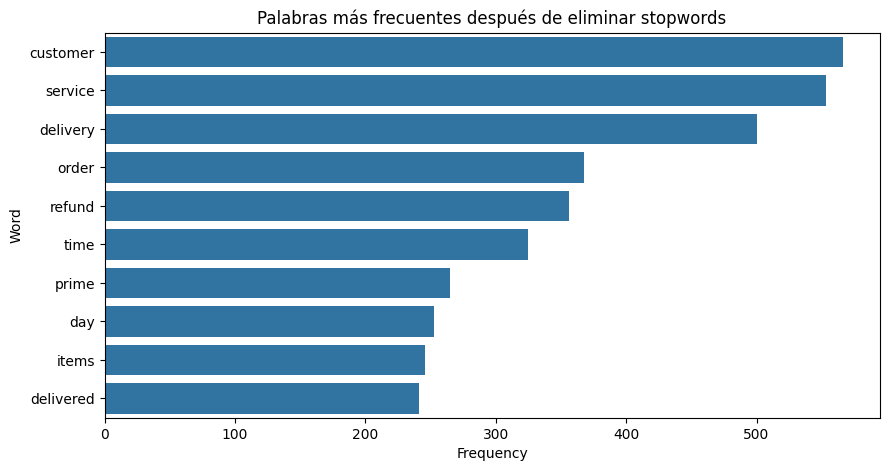

In [23]:
## Visualizacion

plt.figure(figsize=(10,5))

sns.barplot(
    data=after_df,
    x="Frequency",
    y="Word"
)

plt.title(
    "Palabras más frecuentes después de eliminar stopwords"
)

plt.show()